###Untuk soal nomor 1 dan nomor 6 ada di dokumen yg berada di drive

###2. Data Understanding, jabarkan apa yang menjadi target variable? Buatkan visualisasi tahapan Exploratory Data Analysis untuk melihat beberapa hubungan 2 variable dengan target variable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data-bank.csv")

In [ ]:
print("5 data")
display(df.head())

5 data


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
print("informasi")
df.info()

informasi
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-t

In [ ]:
print("deskripsi numerik")
display(df.describe())

deskripsi numerik


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


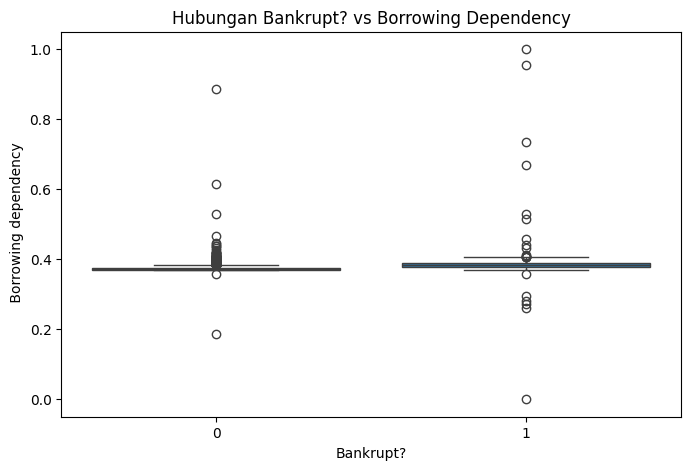

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Bankrupt?', y=' Borrowing dependency')
plt.title("Hubungan Bankrupt? vs Borrowing Dependency")
plt.show()

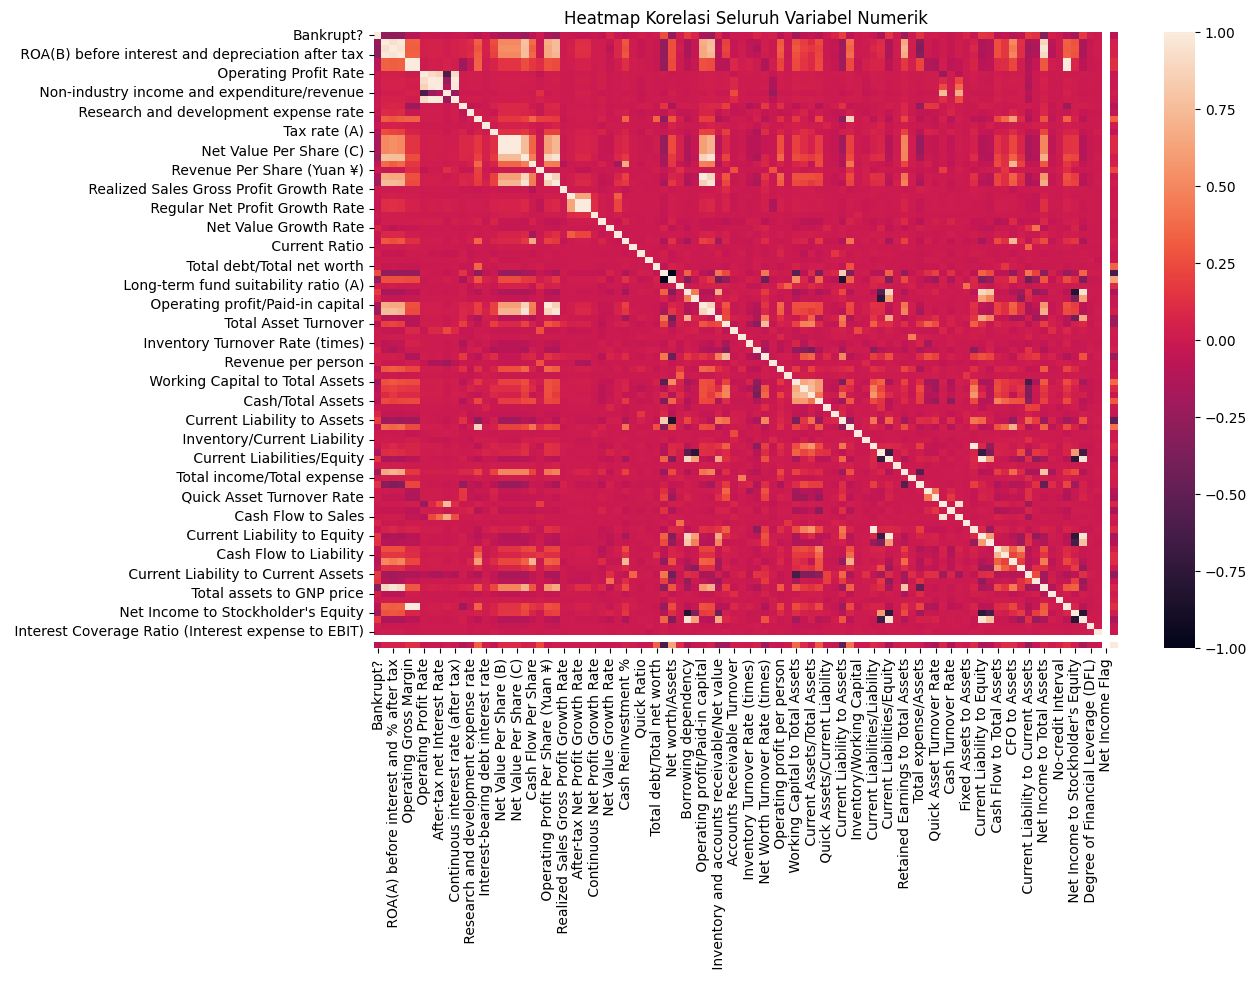

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Heatmap Korelasi Seluruh Variabel Numerik")
plt.show()


### 3. Data Preparation, Apakah data ini “Balance”? dan jika tidak, bagaimana cara untuk menangani data yang tidak balance? Buatkan juga tahapan data cleaning dan data transformation nya.

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    0.968
1    0.032
Name: count, dtype: float64


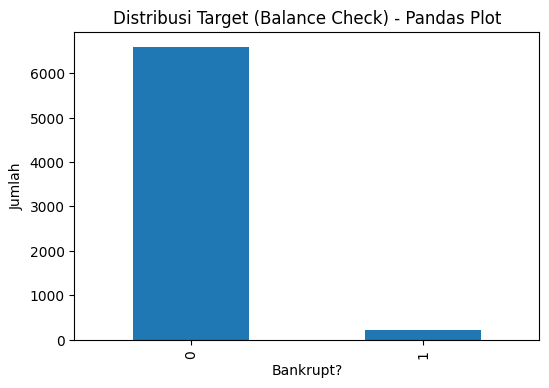

In [ ]:
# Distribusi kelas
print(df['Bankrupt?'].value_counts())
print((df['Bankrupt?'].value_counts() / len(df)).round(3))

# Visualisasi menggunakan pandas bawaan
df['Bankrupt?'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribusi Target (Balance Check) - Pandas Plot")
plt.xlabel("Bankrupt?")
plt.ylabel("Jumlah")
plt.show()

In [ ]:
# Buat objek oversampler
ros_alt = RandomOverSampler(sampling_strategy='minority', random_state=42)

# Fit-resample
X_over_alt, y_over_alt = ros_alt.fit_resample(
    df.drop(columns=['Bankrupt?']),
    df['Bankrupt?']
)

print("Hasil Oversampling:\n", y_over_alt.value_counts())

# Buat objek undersampler
rus_alt = RandomUnderSampler(sampling_strategy='majority', random_state=42)
# Fit-resample
X_under_alt, y_under_alt = rus_alt.fit_resample(
    df.drop(columns=['Bankrupt?']),
    df['Bankrupt?']
)
print("Hasil Undersampling:\n", y_under_alt.value_counts())

# Buat objek SMOTE
smote_alt = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
# Terapkan SMOTE ke data training
X_train_sm_alt, y_train_sm_alt = smote_alt.fit_resample(X_train, y_train)
print("Hasil SMOTE:\n", y_train_sm_alt.value_counts())



Hasil Oversampling:
 Bankrupt?
1    6599
0    6599
Name: count, dtype: int64
Hasil Undersampling:
 Bankrupt?
0    220
1    220
Name: count, dtype: int64
Hasil SMOTE:
 Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [ ]:
# Cek missing value
print(df.isna().sum())

# Menghapus baris yang memiliki semua nilai NaN
df_alt = df.dropna(how='all')

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64


In [ ]:
dup_count = df_alt.duplicated().sum()
print("Jumlah duplikat:", dup_count)

df_alt = df_alt.drop_duplicates()

Jumlah duplikat: 0


In [ ]:
from scipy import stats
# Hitung z-score untuk semua kolom numerik
num_cols_alt = df_alt.select_dtypes(include=['float64', 'int64']).columns

In [ ]:
df_alt.columns = [col.strip().replace(" ", "_").lower() for col in df_alt.columns]

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded_alt = df_alt.copy()
label = LabelEncoder()

for c in df_encoded_alt.select_dtypes(include='object').columns:
    df_encoded_alt[c] = label.fit_transform(df_encoded_alt[c])

###4. Modelling, Gunakan algoritma seperti Random Forest, Decision Tree, Artificial Neural Network. Manakah algoritma yang paling sesuai dengan dataset yang ada saat ini?


In [ ]:
#model decision tree
dt_alt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_alt.fit(X_train_sm_alt, y_train_sm_alt)

pred_dt_alt = dt_alt.predict(X_test)

print("\n=== DECISION TREE (SMOTE) ===")
print(classification_report(y_test, pred_dt_alt))
print("Accuracy:", accuracy_score(y_test, pred_dt_alt))

#model random forest
rf_alt = RandomForestClassifier(n_estimators=200, random_state=42)
rf_alt.fit(X_over_alt, y_over_alt)

pred_rf_alt = rf_alt.predict(X_test)

print("\n=== RANDOM FOREST (Oversampling) ===")
print(classification_report(y_test, pred_rf_alt))
print("Accuracy:", accuracy_score(y_test, pred_rf_alt))

#model ann
ann_alt = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

ann_alt.fit(X_under_alt, y_under_alt)

pred_ann_alt = ann_alt.predict(X_test)

print("\n=== ANN (Undersampling) ===")
print(classification_report(y_test, pred_ann_alt))
print("Accuracy:", accuracy_score(y_test, pred_ann_alt))




=== DECISION TREE (SMOTE) ===
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1320
           1       0.25      0.68      0.36        44

    accuracy                           0.92      1364
   macro avg       0.62      0.81      0.66      1364
weighted avg       0.96      0.92      0.94      1364

Accuracy: 0.9230205278592375

=== RANDOM FOREST (Oversampling) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1320
           1       1.00      1.00      1.00        44

    accuracy                           1.00      1364
   macro avg       1.00      1.00      1.00      1364
weighted avg       1.00      1.00      1.00      1364

Accuracy: 1.0

=== ANN (Undersampling) ===
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      1320
           1       0.07      0.73      0.13        44

    accuracy                           0.

### 5. Evaluation, Lakukan evaluasi dari model yang anda sudah buat. Sajikan Confusion Matrix, Precision, Recall, f1-score dan sebagainya

=== Evaluation: Decision Tree (ALT) ===
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1320
           1       0.25      0.68      0.36        44

    accuracy                           0.92      1364
   macro avg       0.62      0.81      0.66      1364
weighted avg       0.96      0.92      0.94      1364



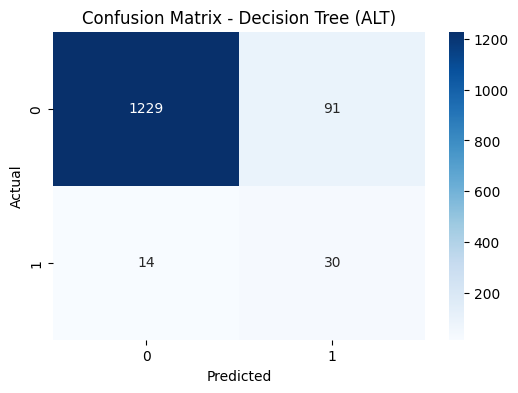

=== Evaluation: Random Forest (ALT) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1320
           1       1.00      1.00      1.00        44

    accuracy                           1.00      1364
   macro avg       1.00      1.00      1.00      1364
weighted avg       1.00      1.00      1.00      1364



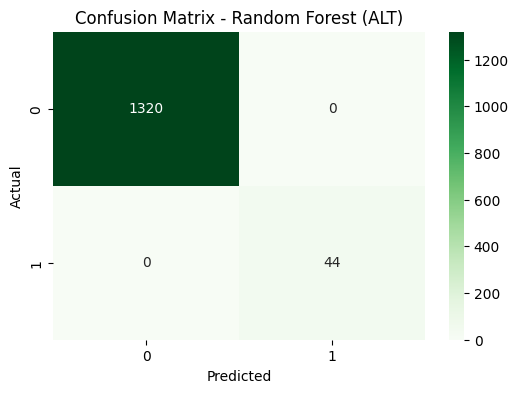

=== Evaluation: ANN (ALT) ===
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      1320
           1       0.07      0.73      0.13        44

    accuracy                           0.70      1364
   macro avg       0.53      0.71      0.47      1364
weighted avg       0.96      0.70      0.79      1364



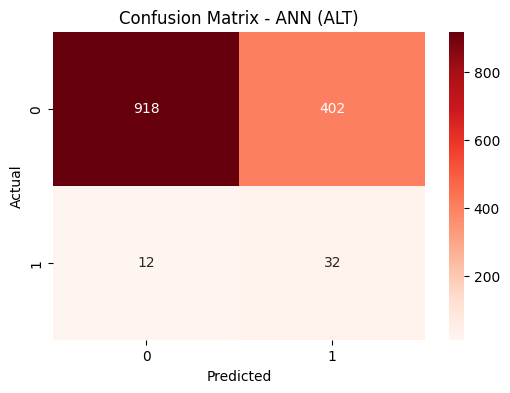

In [ ]:
# === Evaluasi Decision Tree ===
print("=== Evaluation: Decision Tree (ALT) ===")
print(classification_report(y_test, pred_dt_alt))

cm_dt_alt = confusion_matrix(y_test, pred_dt_alt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt_alt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree (ALT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# === Evaluasi Random Forest ===
print("=== Evaluation: Random Forest (ALT) ===")
print(classification_report(y_test, pred_rf_alt))

cm_rf_alt = confusion_matrix(y_test, pred_rf_alt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_alt, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest (ALT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# === Evaluasi ANN ===
print("=== Evaluation: ANN (ALT) ===")
print(classification_report(y_test, pred_ann_alt))

cm_ann_alt = confusion_matrix(y_test, pred_ann_alt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ann_alt, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - ANN (ALT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
